#### Test plotting functions using the H2H2 data.

Total Energy Difference: -1.38e-03 %


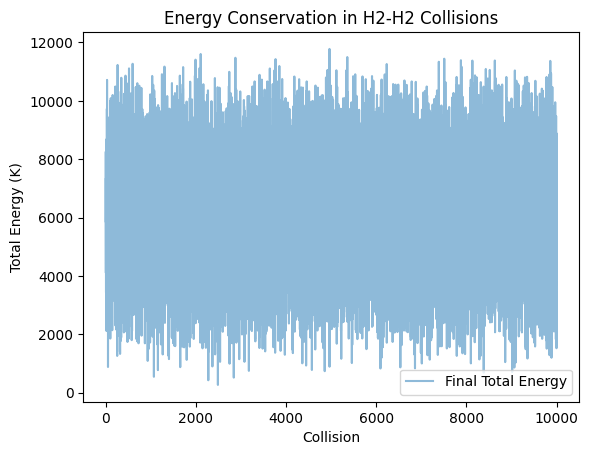

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# Check energy conservation
datafile = "data/H2H2_collisionsV3.csv"
df = pd.read_csv(datafile, skiprows=1)
Etot_init = df.iloc[:,0] + df.iloc[:,1] + df.iloc[:,2]
Etot_final = df.iloc[:,3] + df.iloc[:,4] + df.iloc[:,5]

total_energy_diff = 100* np.sum(Etot_final - Etot_init) / np.sum(Etot_init)
print(f'Total Energy Difference: {total_energy_diff:.2e} %')
plt.plot(Etot_final, label='Final Total Energy', alpha=0.5)
plt.xlabel('Collision')
plt.ylabel('Total Energy (K)')
plt.title('Energy Conservation in H2-H2 Collisions')
plt.legend()
plt.show()


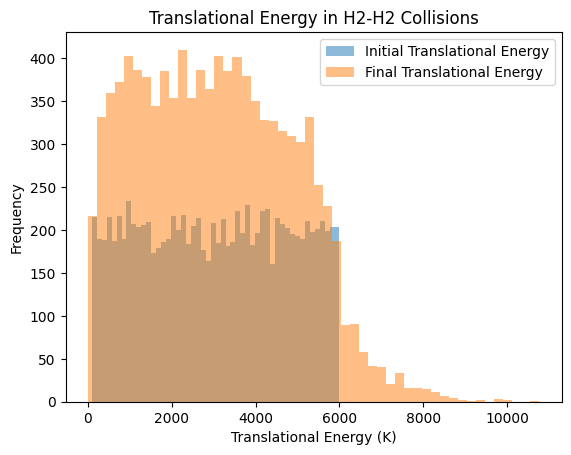

In [28]:
Etr_init = df.iloc[:,0]
Etr_final = df.iloc[:,3]
plt.hist(Etr_init, bins=50, alpha=0.5, label='Initial Translational Energy')
plt.hist(Etr_final, bins=50, alpha=0.5, label='Final Translational Energy')
plt.xlabel('Translational Energy (K)')
plt.ylabel('Frequency')
plt.title('Translational Energy in H2-H2 Collisions')
plt.legend()
plt.show()

This indicates the energy distribution nudges toward equilibrium over many collisions.

Average initial translational fraction: 0.481
Average final translational fraction (CTC): 0.485


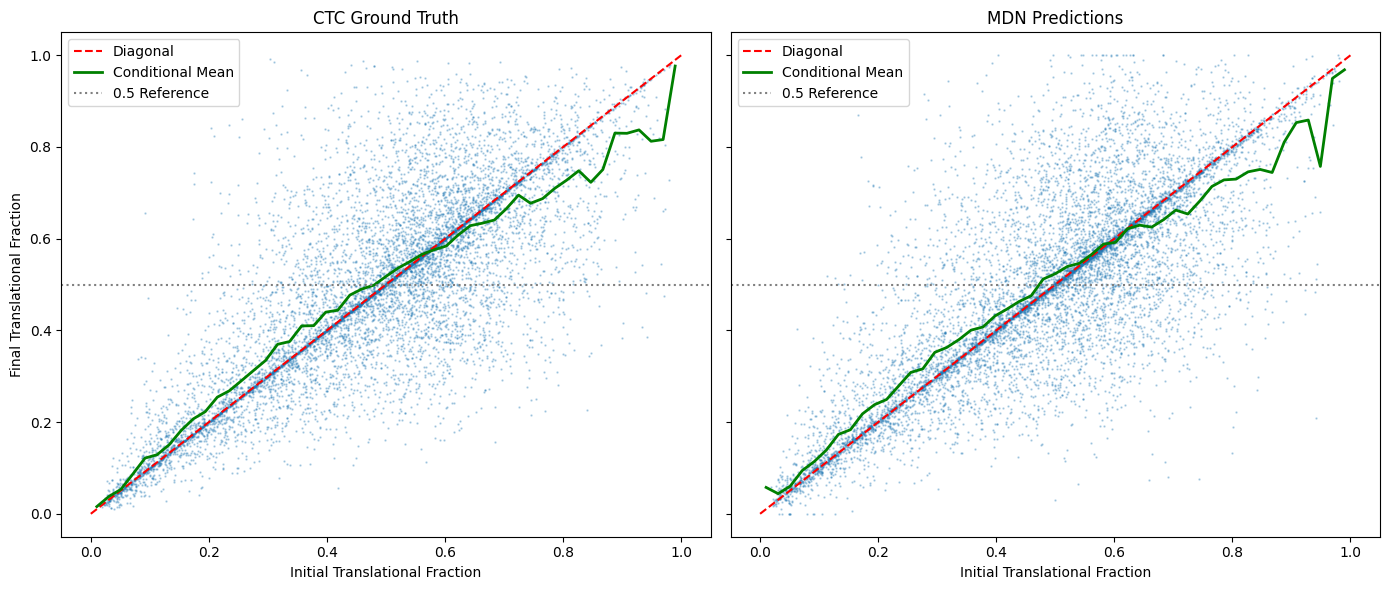

In [29]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from machinelearning.mdn import MixtureDensityNetwork
from config.experiment_config import ExperimentConfig

experiment_config = ExperimentConfig()

mdn = MixtureDensityNetwork(
    input_dim=3, output_dim=2, num_mixtures=5, hidden_dim=experiment_config.hidden_dim, randomseed=42
)
mdn.load_model("results/models/mdn_H2H2.pth")

# Load CTC data
df = pd.read_csv(datafile)

Etr = df.iloc[1:,0]
Erot_A = df.iloc[1:,1]
Erot_B = df.iloc[1:,2]
Erot = Erot_A + Erot_B
Etot = Etr + Erot
eta_tr = Etr/Etot
eta_rot_A = Erot_A/Erot

Etr_out = df.iloc[1:,3]
Erot_A_out = df.iloc[1:,4]
Erot_B_out = df.iloc[1:,5]
Erot_out = Erot_A_out + Erot_B_out
Etot_out = Etr_out + Erot_out
eta_tr_out = Etr_out/Etot_out
eta_rot_A_out = Erot_A_out/Erot_out


# Build MDN input: [E_available, eta_tr, eta_rot_A]
input_features = torch.tensor(
    np.stack([Etot, eta_tr, eta_rot_A], axis=1), dtype=torch.float32
)

# Sample post-collision fractions from MDN
samples = mdn.sample(input_features).detach().cpu().numpy()
xi_rel_post = np.clip(samples[:, 0], 0.0, 1.0)

# Binned conditional means
bins = np.linspace(0, 1, 50)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
digitized = np.digitize(eta_tr, bins)

ctc_mean = np.array([eta_tr_out[digitized == i].mean() if np.any(digitized == i) else np.nan for i in range(1, len(bins))])
mdn_mean = np.array([xi_rel_post[digitized == i].mean() if np.any(digitized == i) else np.nan for i in range(1, len(bins))])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# CTC plot
axes[0].scatter(eta_tr, eta_tr_out, alpha=0.3, s=0.5)
axes[0].plot([0, 1], [0, 1], "r--", label="Diagonal")
axes[0].plot(bin_centers, ctc_mean, "g-", linewidth=2, label="Conditional Mean")
axes[0].axhline(0.5, color="gray", linestyle=":", label="0.5 Reference")
axes[0].set_xlabel("Initial Translational Fraction")
axes[0].set_ylabel("Final Translational Fraction")
axes[0].set_title("CTC Ground Truth")
axes[0].legend()

# MDN plot
axes[1].scatter(eta_tr, xi_rel_post, alpha=0.3, s=0.5)
axes[1].plot([0, 1], [0, 1], "r--", label="Diagonal")
axes[1].plot(bin_centers, mdn_mean, "g-", linewidth=2, label="Conditional Mean")
axes[1].axhline(0.5, color="gray", linestyle=":", label="0.5 Reference")
axes[1].set_xlabel("Initial Translational Fraction")
axes[1].set_title("MDN Predictions")
axes[1].legend()

# Print average fractions
print(f"Average initial translational fraction: {eta_tr.mean():.3f}")
print(f"Average final translational fraction (CTC): {eta_tr_out.mean():.3f}")

plt.tight_layout()
plt.show()

This seems wrong because for a collision pair the translational energy fraction is determined by the DOF. In this case that is 3 translational DOF (since we only look at relative velocity) and 2 + 2 rotational DOF (since we have two H2 molecules). So the expected translational energy fraction is 3 / (3 + 2 + 2) = 0.43, which is not what we see in the plot. This might be the case because the Lennart-Jones potential used for generating the data does not realistically model the molecule collisions.